In [ ]:
import marimo as mo

# Bayes opt loop design with failure regions

Our optimization problem has an issue: designs that are not monotonic are not statistically possible. However, while exploring the search space, there is no restriction on monotonicity. In initial testing, penalizing monotonicity does improve model fit, but >90% of designs are still discarded because of non-monotonicity.

In order to solve this issue, rather than penalizing monotonicity, we will define this as a failure region. The penalty function will return finite values for feasible designs and will return `np.nan` for designs that are statistically impossible.

The Bayesian optimization loop will then fit two models: (1) a Gaussian process regression (GPR) model for the feasible designs and their objective function and (2) a variational Gaussian process (VPR) classification model with Bernoulli likelihood to model the failure region.

The steps are as follows:
1. Generate the 3 initial points, Pocock, O'Brien-Fleming, and triagular bounds and penalty values.
2. The objective function $f(\cdot)\in\mathbb{R}^+$ takes as input the study design $D$ and outputs $y=\{f(D),1\}$ if the design is feasible and $y=\{\texttt{np.nan}, 0\}$ if the study design is statistically impossible.
3. Fit the two models (1) GPR for the real-valued $f(D)$ and (2) a VPR for the indicator $\{0,1\}$ for statistical possibility.
4. Run the Bayesian optimization loop

The goal of this type of model is to increase the number of feasible designs output by the model in a way that differs from only penalizing statistically impossible designs with large $f(D)$.

# Simplified example of failure region objective function output

In [ ]:
# a simplified example of step 2's objective function
def objective_function(D):
    if np.isfinite(D):
        return (3, 1)
    else:
        return (np.nan, 0)

In [ ]:
# example output for a feasible design D1 = 3
D1 = 3
objective_function(D1)

In [ ]:
# example output for a statistically impossible desing D2 = np.nan
D2 = np.nan
objective_function(D2)

The $\{0,1\}$ output is used to train the classification model and the real value is used to train the regression model.

# Setup required imports

In [ ]:
# scientific computing imports
import numpy as np
import pandas as pd
from scipy import stats
from scipy import optimize
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf

2026-04-20 17:42:37.279342: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 17:42:37.299505: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-20 17:42:37.299524: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-20 17:42:37.300098: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-20 17:42:37.303845: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
# imports for GP regression
import gpflow
from gpflow.keras import tf_keras

/usr/local/lib/python3.10/dist-packages/gpflow/versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
import trieste
from trieste.space import Box

# for the two models to be used
from trieste.models.gpflow.models import GaussianProcessRegression
from trieste.models.gpflow.models import VariationalGaussianProcess

# to combine the two models into a dictionary
from trieste.models import TrainableProbabilisticModel
from trieste.types import Tag

# to select the Adam optimizer
from trieste.models.optimizer import BatchOptimizer

# to create custom aquisition function
from trieste.acquisition.rule import EfficientGlobalOptimization
from trieste.acquisition import (
    SingleModelAcquisitionBuilder,
    ExpectedImprovement,
    Product,
)

2026-04-20 17:42:49.768280: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 17:42:49.773516: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-20 17:42:49.774434: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [ ]:
# group sequential design assessment imports
from py_group_sequential_designs import generate_boundaries as bd
from py_group_sequential_designs import feasibility_penalty as fp
from py_group_sequential_designs import boundary_manipulations as fmt_bd
from py_group_sequential_designs import function_to_minimize as fn_min
from py_group_sequential_designs import generate_gpr_input as gen_input
from py_group_sequential_designs import simulate as sim
from py_group_sequential_designs import sample_size as ss

# Set the defaults for this Bayes opt run

In [ ]:
# some set defaults
num_analyses = 3
target_alpha = 0.05
target_power = 0.9
important_diff_delta = 1
assumed_variance = 3

# to obtain mu (sample size at one stage)
mu = ss.sample_size_means(
    ratio=1,
    variance=assumed_variance,
    power=target_power,
    alpha=target_alpha,
    delta=important_diff_delta
)

# Create an objective function that returns NaN as failure

In [ ]:
# this function contains a penalty for non-monotonicity
def observe_new_xy(
        mu,
        upper_bounds,
        lower_bounds,
        n_analyses,
        target_power,
        target_alpha,
        alpha_prime,
        beta_prime,
        n_power09):

    # 2. Generate the GPR input values
    # note that the input includes the sample size at power 0.9
    x = gen_input.generate_gpr_input(
        n_analyses = n_analyses,
        upper_bounds=upper_bounds,
        lower_bounds=lower_bounds,
        n_patients=n_power09)

    # if the input value are not monotonic, don't bother with
    # all the below calculations
    if fmt_bd.check_monotonicity(n_analyses=num_analyses, bounds=x) == False:
        y = np.nan

        return {
            "failure" : {
                "x" : np.array([x]),
                "y" : np.array([[tf.cast(np.isfinite(y), tf.float64)]])
            }
        }

    else:
        # 3. Generate maximum expected sample size and feasibility penalty
        max_ess_new = ss.max_ess(
            n_analyses=n_analyses,
            upper_bounds=upper_bounds,
            lower_bounds=lower_bounds,
            n_patients=n_power09)

        penalty = fp.smooth_penalty(
            mu = mu,
            power=target_power,
            alpha=target_alpha,
            beta_prime=beta_prime,
            alpha_prime=alpha_prime
        )

        y = fn_min.function_to_minimize(max_ess_val=max_ess_new/mu, penalty=penalty)

        return {
            "objective" : {
                "x" : np.array([x]),
                "y" : np.array([[y]])
            },
            "failure" : {
                "x" : np.array([x]),
                "y" : np.array([[tf.cast(np.isfinite(y), tf.float64)]])
            }
        }

# Generate initial input/output dataset

## Point 1 - Pocock

In [ ]:
# simulate the trial design 
poc_simulation = bd.calculate_pocock_boundaries(
    n_analyses=num_analyses,
    alpha=target_alpha,
    n_patients=20
)

# find the number of patients that achieves 90% power (beta 0.1)
# here we get beta_prime
poc_n_power09, poc_power = ss.find_sample_size(
    n_analyses = num_analyses,
    upper_bounds = poc_simulation[0],
    lower_bounds = poc_simulation[1],
    alt_hypothesis = important_diff_delta,
    variance = assumed_variance
)

point1 = observe_new_xy(
    mu = mu,
    upper_bounds = poc_simulation[0],
    lower_bounds = poc_simulation[1],
    n_analyses = num_analyses,
    target_power = target_power,
    target_alpha = target_alpha,
    alpha_prime = poc_simulation[3],
    beta_prime = 1-poc_power,
    n_power09 = poc_n_power09
)

In [ ]:
point1

In [ ]:
point1["objective"]

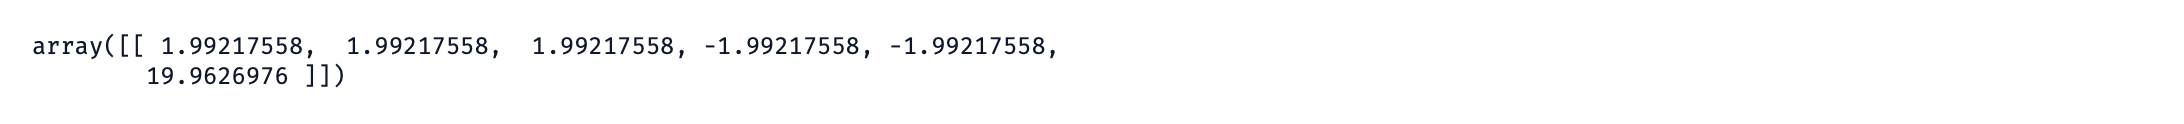

In [ ]:
point1["objective"]["x"]

In [ ]:
point1["failure"]

## Point 2 - O'Brein-Fleming

In [ ]:
# simulate the trial design 
of_simulation = bd.calculate_of_boundaries(
    n_analyses=num_analyses,
    alpha=target_alpha,
    n_patients=20
)

# find the number of patients that achieves 90% power (beta 0.1) and beta_prime
of_n_power09, of_power = ss.find_sample_size(
    n_analyses = num_analyses,
    upper_bounds = of_simulation[0],
    lower_bounds = of_simulation[1],
    alt_hypothesis = important_diff_delta,
    variance = assumed_variance
)

point2 = observe_new_xy(
    mu = mu,
    upper_bounds = of_simulation[0],
    lower_bounds = of_simulation[1],
    n_analyses = num_analyses,
    target_power = target_power,
    target_alpha = target_alpha,
    alpha_prime = of_simulation[3],
    beta_prime = 1-of_power,
    n_power09 = of_n_power09
)

In [ ]:
point2["objective"]

In [ ]:
point2["failure"]

## Point 3 - Triangular

In [ ]:
# simulate the trial design 
tri_simulation = bd.calculate_triangular_boundaries(
    n_analyses=num_analyses,
    alpha=target_alpha,
    delta=important_diff_delta,
    n_patients=20
)

# find the number of patients that achieves 90% power (beta 0.1) and beta_prime
tri_n_power09, tri_power = ss.find_sample_size(
    n_analyses = num_analyses,
    upper_bounds = tri_simulation[0],
    lower_bounds = tri_simulation[1],
    alt_hypothesis = important_diff_delta,
    variance = assumed_variance
)

point3 = observe_new_xy(
    mu = mu,
    upper_bounds = tri_simulation[0],
    lower_bounds = tri_simulation[1],
    n_analyses = num_analyses,
    target_power = target_power,
    target_alpha = target_alpha,
    alpha_prime = tri_simulation[3],
    beta_prime = 1-tri_power,
    n_power09 = tri_n_power09
)

In [ ]:
point3["objective"]

In [ ]:
point3["failure"]

In order for the functions below to work, we need  a Trieste dataset as a dictionary with:

```
initial_data = {
    "objective": trieste.data.Dataset(query_points = x, observations = y),
    "failure"  : trieste.data.Dataset(query_points = x, observations = y)
}
```

where

```
x = np.array(
    [
     [x1],
     [x2]
    ]
)
```

and y similarly.

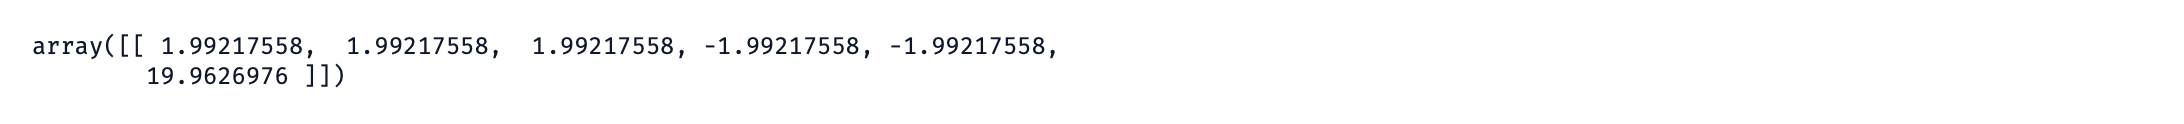

In [ ]:
point1["objective"]["x"]

In [ ]:
objective_query_points = np.concatenate(
    (
        point1["objective"]["x"],
        point2["objective"]["x"],
        point3["objective"]["x"]
    )
)

In [ ]:
objective_observations = np.concatenate(
    (
        point1["objective"]["y"],
        point2["objective"]["y"],
        point3["objective"]["y"]
    )
)

In [ ]:
failure_query_points = np.concatenate(
    (
        point1["failure"]["x"],
        point2["failure"]["x"],
        point3["failure"]["x"]
    )
)

In [ ]:
failure_observations = np.concatenate(
    (
        point1["failure"]["y"],
        point2["failure"]["y"],
        point3["failure"]["y"]
    )
)

In [ ]:
initial_data = {
    "objective" : trieste.data.Dataset(query_points = objective_query_points, observations = objective_observations),
    "failure"   : trieste.data.Dataset(query_points = failure_query_points, observations = failure_observations)
}

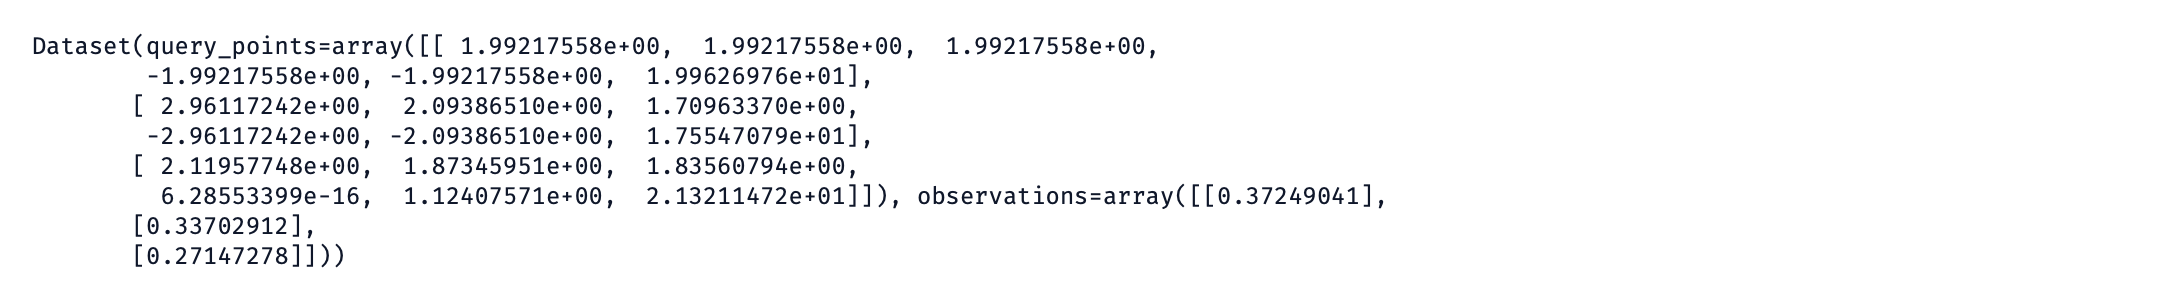

In [ ]:
initial_data["objective"]

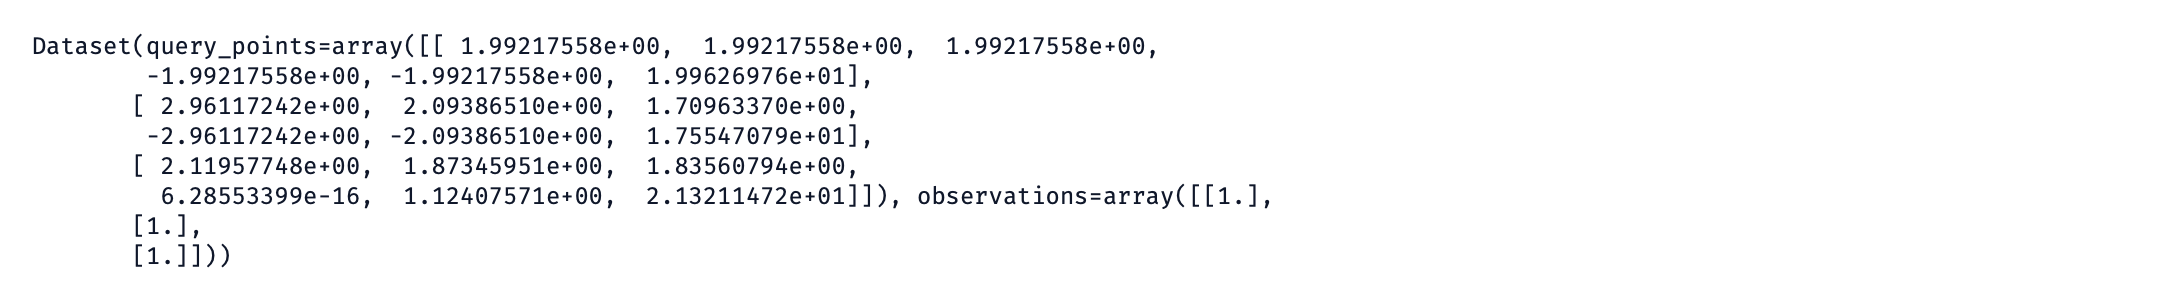

In [ ]:
initial_data["failure"]

# Build the models for objective and failure

## GPR

In [ ]:
def build_gpr_model(X, Y, kernel, likelihood):

    gpr = gpflow.models.GPR(
        data = (X, Y),
        kernel = kernel,
        likelihood = likelihood
    )

    gpflow.utilities.print_summary(gpr)

    return gpr

## GPR kernel

In [ ]:
gpr_kernel = gpflow.kernels.Matern52()

# there are 6 dimension in the input requiring 6-d lengthscales
# upper1, upper2, upper3, lower1, lower2, n
gpr_kernel.lengthscales = gpflow.Parameter(value = [1, 1, 1, 1, 1, 1], trainable = True)

gpr_likelihood = gpflow.likelihoods.Gaussian()

2026-04-20 17:45:47.287680: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:225] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 12.0
2026-04-20 17:45:47.287691: W external/local_xla/xla/stream_executor/gpu/asm_compiler.cc:228] Used ptxas at ptxas
2026-04-20 17:45:47.287716: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:45:47.348808: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:45:47.349510: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:45:47.349537: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191]

## Build the GPR model

In [ ]:
gpr_model = build_gpr_model(
    X = initial_data["objective"].query_points, 
    Y = initial_data["objective"].observations,
    kernel = gpr_kernel,
    likelihood = gpr_likelihood
)

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤════════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value          │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪════════════════╡
│ GPR.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0            │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ GPR.kernel.lengthscales │ Parameter │ Identity         │         │ True        │ (6,)    │ float64 │ [1., 1., 1.... │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼────────────────┤
│ GPR.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()      │ float64 │ 1.0            │
╘═════════════════════════╧═══════════╧═

## VGP

In [ ]:
def build_vgp_model(X, Y, kernel, likelihood):

    vgp = gpflow.models.VGP(
        data = (X, Y),
        kernel = kernel,
        likelihood = likelihood
    )

    gpflow.utilities.print_summary(vgp)

    return vgp

## VGP kernel

In [ ]:
vgp_kernel = gpflow.kernels.SquaredExponential()

# there are 6 dimension in the input requiring 6-d lengthscales
# upper1, upper2, upper3, lower1, lower2, n
vgp_kernel.lengthscales = gpflow.Parameter(value = [1, 1, 1, 1, 1, 1], trainable = True)

vgp_likelihood = gpflow.likelihoods.Bernoulli()

## Build VGP model

In [ ]:
vgp_model = build_vgp_model(
    X = initial_data["failure"].query_points, 
    Y = initial_data["failure"].observations,
    kernel = gpr_kernel,
    likelihood = gpr_likelihood
) 

╒═════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═══════════╤═════════╤══════════════════╕
│ name                    │ class     │ transform        │ prior   │ trainable   │ shape     │ dtype   │ value            │
╞═════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═══════════╪═════════╪══════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus         │         │ True        │ ()        │ float64 │ 1.0              │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────┼─────────┼──────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Identity         │         │ True        │ (6,)      │ float64 │ [1., 1., 1....   │
├─────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼───────────┼─────────┼──────────────────┤
│ VGP.likelihood.variance │ Parameter │ Softplus + Shift │         │ True        │ ()        │ float64 │ 1.0              │
├───────

# Create a custom aquisition function with these two models

In [ ]:
# combine the models
models: dict[Tag, TrainableProbabilisticModel] = {

    "objective": GaussianProcessRegression(model = gpr_model),

    "failure"  : VariationalGaussianProcess(
        model = vgp_model,
        optimizer = BatchOptimizer(
            tf_keras.optimizers.Adam(learning_rate = 1e-3)
        ),
        use_natgrads = True
    )

}

2026-04-20 17:46:23.302623: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:46:27.050307: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:46:27.051374: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:46:27.051393: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:46:27.051400: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20

In [ ]:
# custom aquisition
class ProbabilityOfValidity(SingleModelAcquisitionBuilder):
    def prepare_acquisition_function(self, model, dataset=None):
        def acquisition(at):
            mean, _ = model.predict_y(tf.squeeze(at, -2))
            return mean

        return acquisition


ei = ExpectedImprovement()
pov = ProbabilityOfValidity()
acq_fn = Product(ei.using("objective"), pov.using("failure"))
rule = EfficientGlobalOptimization(
    acq_fn,
    optimizer = trieste.acquisition.optimizer.generate_continuous_optimizer(
            num_optimization_runs = 5000
        )
)  # type: ignore

# Initialize `ask_tell` interface

In [ ]:
# define the search space
search_space = Box(
    lower = [-3,-3,-3,-3,-3, 10], 
    upper = [ 3, 3, 3, 3, 3, 30]
)

In [ ]:
ask_tell = trieste.ask_tell_optimization.AskTellOptimizer(
    search_space = search_space,
    datasets = initial_data,
    models = models,
    acquisition_rule = rule
)

2026-04-20 17:46:40.970873: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:46:41.341145: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:46:43.432468: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:46:49.069250: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:46:49.069266: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20

# Run the Bayes opt loop

In [ ]:
num_repeats = 1000
when_to_print = 50

for _i in range(num_repeats):

    # get the next set of query points
    x_results = ask_tell.ask()

    # format them for calculations
    new_inputs = fmt_bd.format_boundaries_after_ask(
        n_analyses = num_analyses,
        result = x_results
    )

    # initialize an empty dictionary for the `.tell()` data
    new_data = dict()

    # if the results are not monotonic, then don't bother with the below
    if fmt_bd.check_monotonicity(n_analyses=num_analyses, bounds=x_results[0]) == False:

        # observation for the objective is NaN
        # create the new data object as a Trieste dataset
        new_data["failure"] = trieste.data.Dataset(
            query_points = x_results, 
            observations = np.array(
                tf.cast(False, tf.float64), ndmin=2
            )
        )

        new_data["objective"] = trieste.data.Dataset(
            query_points=np.reshape(np.array([]), newshape=(0, x_results.shape[1])), 
            observations=np.reshape(np.array([]), newshape=(0, 1))
        )


    else:

        new_sim_trial = sim.group_sequential_designs(
            n_analyses = num_analyses,
            upper_bounds = new_inputs[0],
            lower_bounds = new_inputs[1],
            n_patients = new_inputs[2],
            null_hypothesis = 0,
            alt_hypothesis = important_diff_delta,
            variance = assumed_variance
        )

        new_point = observe_new_xy(
            mu = mu,
            upper_bounds = new_inputs[0],
            lower_bounds= new_inputs[1],
            n_analyses = num_analyses,
            target_power = target_power,
            target_alpha = target_alpha,
            alpha_prime = new_sim_trial[1],
            beta_prime = 1-new_sim_trial[2],
            n_power09 = new_inputs[2]
        )

        new_data["objective"] = trieste.data.Dataset(
            query_points = new_point["objective"]["x"], 
            observations = new_point["objective"]["y"]
        )

        new_data["failure"] = trieste.data.Dataset(
            query_points = new_point["failure"]["x"],
            observations = new_point["failure"]["y"]
        )

    # tell our Bayes opt loop
    ask_tell.tell(new_data=new_data)

    # print our progress
    if (_i+1) % when_to_print == 0:
        print(f"\nLoop {_i+1} completed.", end="")
    elif (_i > when_to_print) and ((_i+1) % 5 == 0):
        print(".", end="")

2026-04-20 17:47:26.588736: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:47:26.589341: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:47:26.589888: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:47:26.589901: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20 17:47:26.590295: W tensorflow/compiler/mlir/tools/kernel_gen/transforms/gpu_kernel_to_blob_pass.cc:191] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
2026-04-20


Loop 50 completed..........
Loop 100 completed......

....
Loop 150 completed..........
Loop 200 completed..........
Loop 250 completed..........
Loop 300 completed..........
Loop 350 completed..........
Loop 400 completed..........
Loop 450 completed..........
Loop 500 completed..........
Loop 550 completed..........
Loop 600 completed..........
Loop 650 completed..........
Loop 700 completed..........
Loop 750 completed..........
Loop 800 completed..........
Loop 850 completed..........
Loop 900 completed..........
Loop 950 completed..........
Loop 1000 completed.

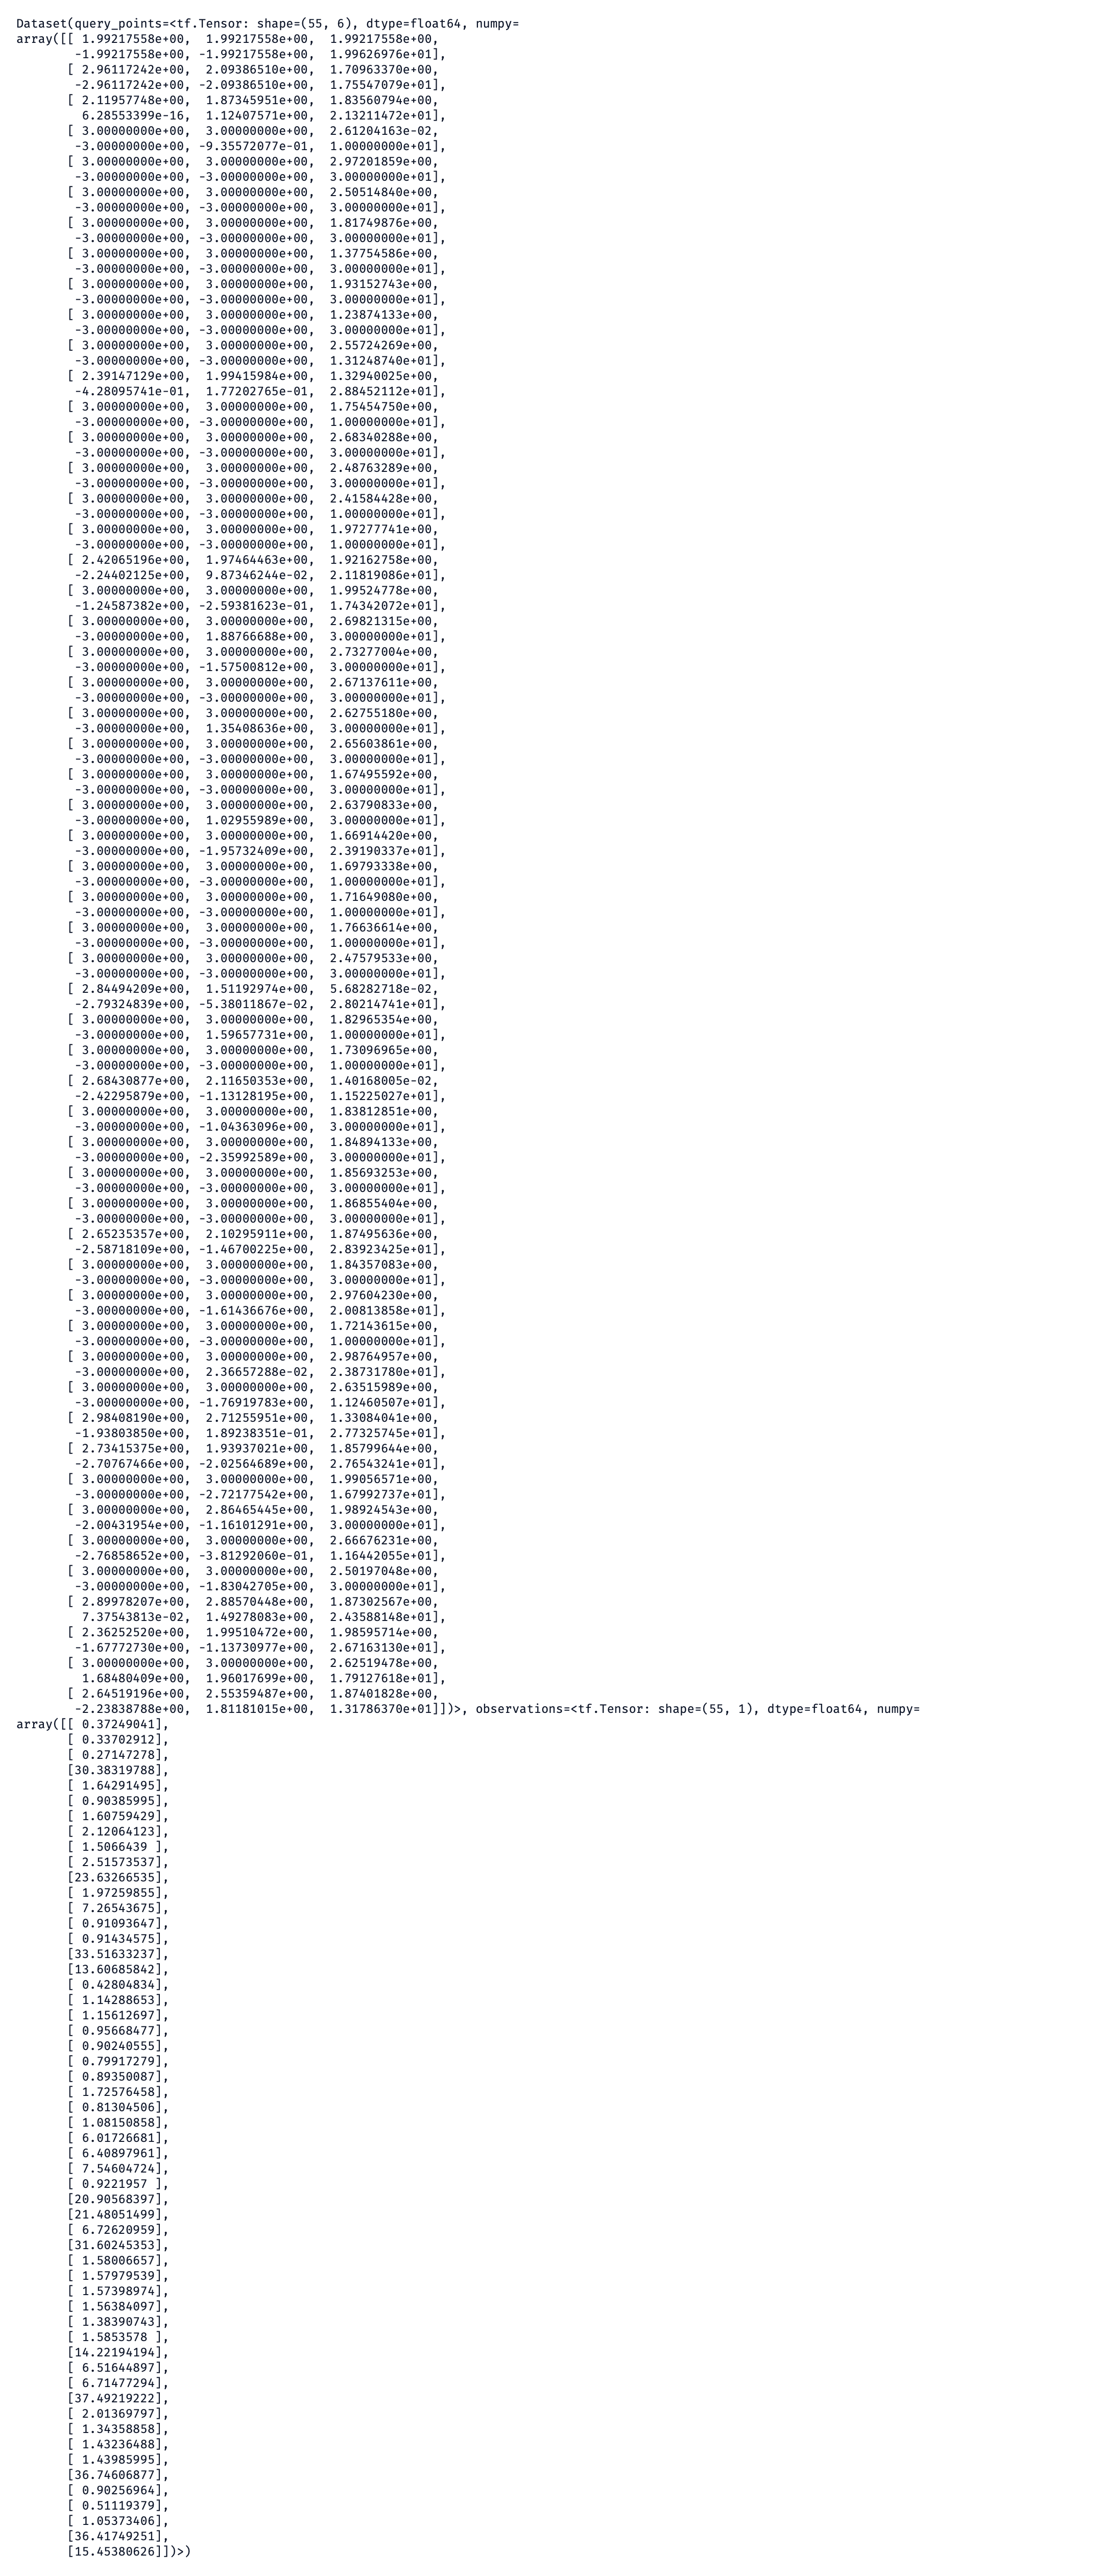

In [ ]:
ask_tell.to_result().try_get_final_datasets()["objective"]

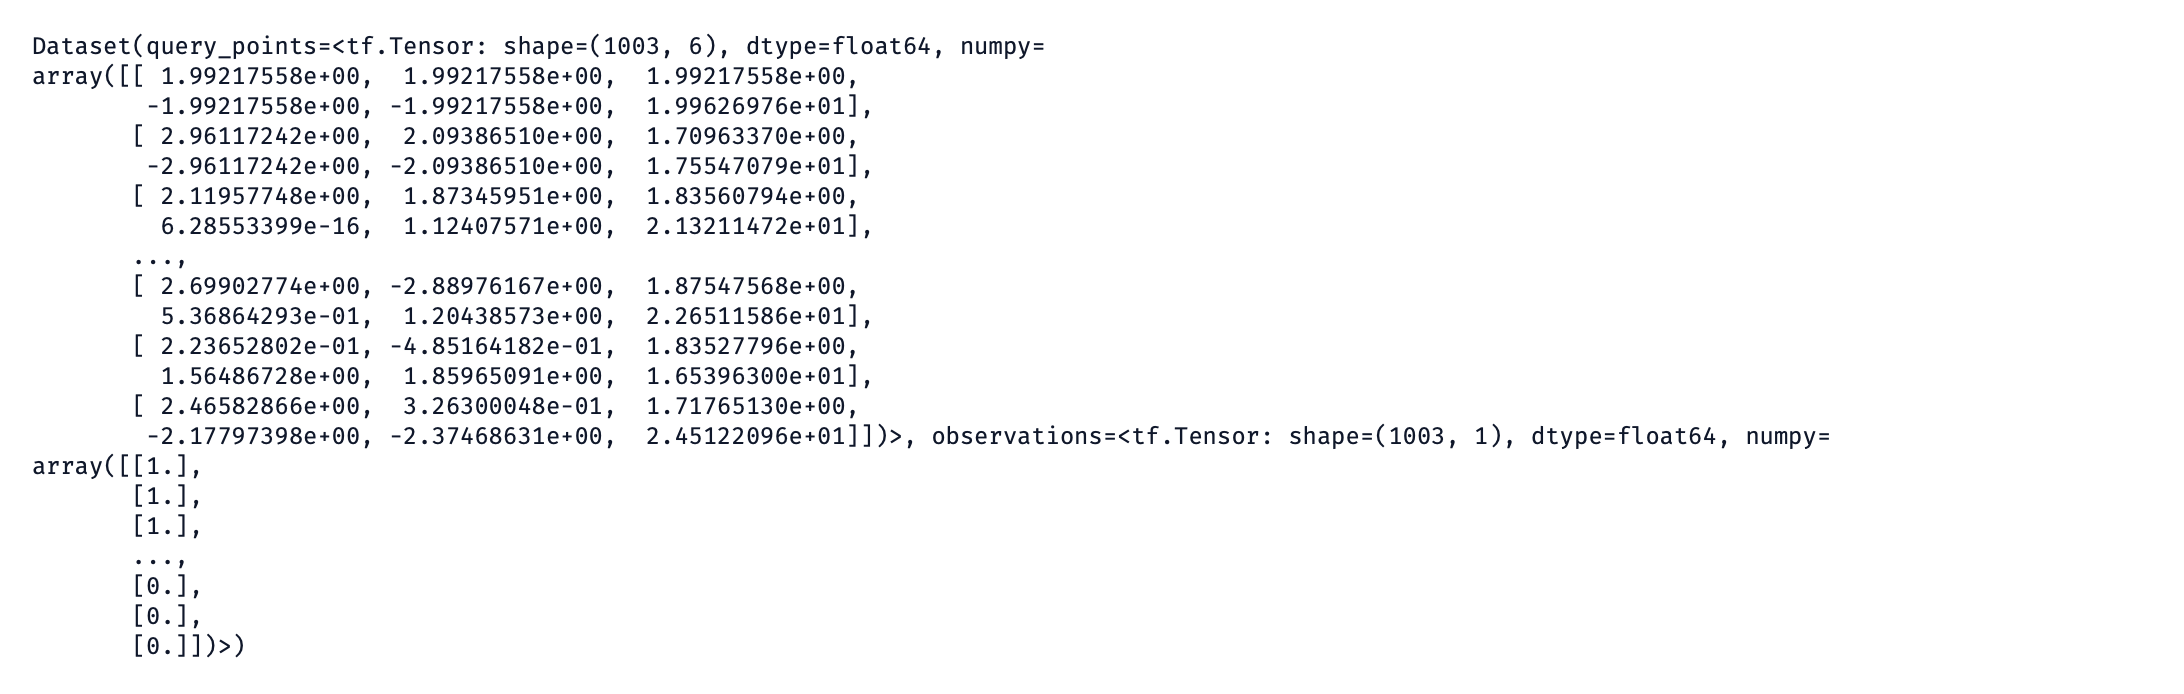

In [ ]:
ask_tell.to_result().try_get_final_datasets()["failure"]

# Summarize the GPR and VGP models

In [ ]:
# print out the model fits
for tag, trieste_model in ask_tell.models.items():
    print(f"Summary for {tag}:")
    gpflow.utilities.print_summary(trieste_model.model)

Summary for objective:
╒═════════════════════════╤══════════════════╤══════════════════╤═════════╤═════════════╤═══════════╤═════════╤═════════════════════════════════════════════════════╕
│ name                    │ class            │ transform        │ prior   │ trainable   │ shape     │ dtype   │ value                                               │
╞═════════════════════════╪══════════════════╪══════════════════╪═════════╪═════════════╪═══════════╪═════════╪═════════════════════════════════════════════════════╡
│ GPR.kernel.variance     │ Parameter        │ Softplus         │         │ True        │ ()        │ float64 │ 171.05368                                           │
├─────────────────────────┼──────────────────┼──────────────────┼─────────┼─────────────┼───────────┼─────────┼─────────────────────────────────────────────────────┤
│ GPR.kernel.lengthscales │ Parameter        │ Identity         │         │ True        │ (6,)      │ float64 │ [5.14542837e+03, 6.41144812e+03, 9.

In [ ]:
sim.group_sequential_designs(
    n_analyses = num_analyses,
    upper_bounds = [ 2.42065196e+00,  1.97464463e+00,  1.92162758e+00],
    lower_bounds = [-2.24402125e+00,  9.87346244e-02,  1.92162758e+00],
    n_patients = 2.11819086e+01,
    null_hypothesis = 0,
    alt_hypothesis = important_diff_delta,
    variance = assumed_variance
)

In [ ]:
point3["objective"]["x"]

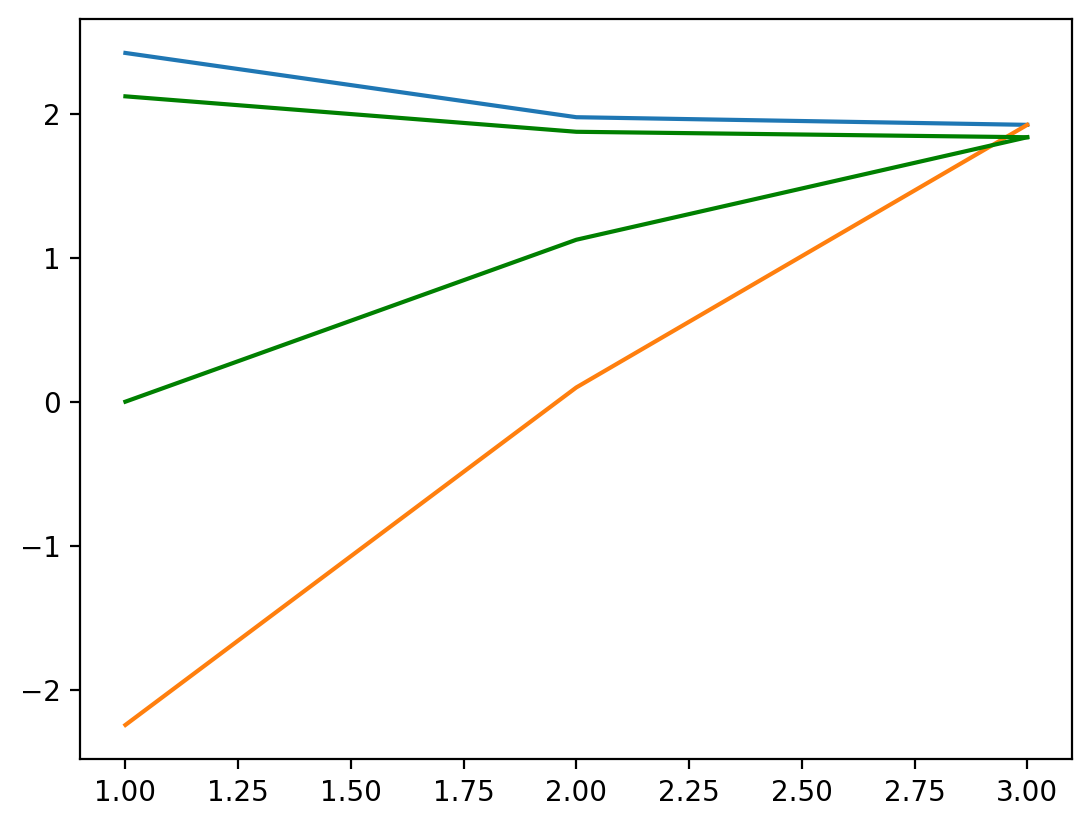

In [ ]:
plt.plot([1, 2, 3], [2.42065196e+00,  1.97464463e+00,  1.92162758e+00])
plt.plot([1,2,3], [-2.24402125e+00,  9.87346244e-02,  1.92162758e+00])
plt.plot([1,2,3], [2.11957748e+00, 1.87345951e+00, 1.83560794e+00],color="green")
plt.plot([1,2,3], [6.28553399e-16, 1.12407571e+00, 1.83560794e+00],color="green")

In [ ]:
failure_region_successes = pd.DataFrame(
    data=ask_tell.to_result().try_get_final_datasets()["objective"].query_points,
    columns=["upper1","upper2","upper3","lower1","lower2","n"]
)

In [ ]:
failure_region_successes_penalty = pd.DataFrame(
    data=ask_tell.to_result().try_get_final_datasets()["objective"].observations,
    columns=["penalty"]
)

In [ ]:
failure_region_bounds = pd.concat([failure_region_successes, failure_region_successes_penalty], axis=1)

In [ ]:
failure_region_bounds.to_csv(path_or_buf="/workspace/2026-03-t16/failure_region_bounds.csv", index=False)

In [ ]:
failures = pd.DataFrame(
    data=ask_tell.to_result().try_get_final_datasets()["failure"].query_points,
    columns=["upper1","upper2","upper3","lower1","lower2","n"]
)

In [ ]:
failures_output = pd.DataFrame(
    data=ask_tell.to_result().try_get_final_datasets()["failure"].observations,
    columns=["output"]
)

In [ ]:
failure_bounds = pd.concat([failures, failures_output], axis=1)

In [ ]:
failure_bounds.to_csv(path_or_buf="/workspace/2026-03-t16/failure_bounds.csv", index=False)